# Modelo final: CatBoost y HGB sobre el precio de Airbnb Nueva York

Este notebook entrena los **dos modelos finalistas** de `3-MODELADO` con **todo el train**, evalúa cada uno en el test,
analiza dónde aciertan y dónde fallan, los interpreta, los guarda y, al final, los compara. Cada sección tiene un
subapartado para CatBoost y otro para HGB, con exactamente el mismo procedimiento.

**Decisiones cerradas antes de abrir el test:**

- **Modelos:** `CatBoost_ajustado`, el de menor RMSE medio de validación (escenario B, conociendo al anfitrión), y
  `HGB_ajustado`, el segundo: CatBoost le gana por 0,003 en CV (5 de 5 folds, menos que la desviación entre folds,
  ~0,009) pero HGB se ajusta unas 16 veces más rápido. Los dos se evalúan en el test para poder describirlos; **cuál
  se presenta como modelo final queda por decidir**. No se elige con el test.
- **Intervalo:** cuantiles 0,1 y 0,9 de cada modelo con sus mismos hiperparámetros, calibrados con **CQR con un solo
  conjunto de calibración**: se ajustan con el train del fold 0 y se calibran con su validación; esos mismos dos modelos
  son los cuantiles finales.
- **Interpretación:** importancia por permutación y PDP/ICE en los dos; SHAP nativo de CatBoost solo en CatBoost.
- **Guardado:** modelo, cuantiles, corrección y ficha en `models/`. Los nombres llevan el sufijo del modelo (`_catboost`, `_hgb`).

**Regla del test:** se carga **una sola vez** (sección 4) y sirve para describir, no para cambiar el modelo, los
hiperparámetros ni las variables.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd().parent / 'scripts'))
from func_modelado import *
from func_final import *

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
MODELS_DIR = PROJECT_ROOT / 'models'
RUTA_REGISTRO = OUTPUT_DIR / 'experimentos.csv'

COLOR_BASE, COLOR_SECUNDARIO = '#2a6f97', '#9aa5b1'
COLORES = {'CatBoost': '#2a6f97', 'HGB': '#eb6834'}
pd.set_option('display.max_columns', 40)

## 1. CARGA DEL TRAIN Y CONFIGURACIÓN DE LOS MODELOS

Los hiperparámetros y las variables se leen del registro de experimentos que hemos ido guardando a medida que los
entrenábamos, no se copian a mano. Se comprueba también el MD5 (huella digital de 32 caracteres) del test **sin
cargarlo**: si no coincide con el de `particion.json`, se para.

In [2]:
train, bloques = cargar_modelado('train')

particion = json.loads((DATA_DIR / 'particion' / 'particion.json').read_text(encoding='utf-8'))
md5_test = md5_fichero(DATA_DIR / 'particion' / 'listings_test.csv')
assert md5_test == particion['md5']['test'], 'El test no coincide con la particion guardada: se para'

folds = cargar_folds(train, OUTPUT_DIR / 'folds_cv.csv', N_REPETICIONES_CV)
FOLDS_MODELOS = [f for f in folds if f.repeticion == 0]

print(f"Train de modelado: {len(train):,} anuncios de {train[COL_GRUPO].nunique():,} anfitriones")
print(f"MD5 del test (sin cargarlo): {md5_test} -> coincide con particion.json")

Train de modelado: 29,538 anuncios de 21,368 anfitriones
MD5 del test (sin cargarlo): 6efbad2d0dd977cb41d7feb0ee114f38 -> coincide con particion.json


### 1.1 CatBoost

In [3]:
hp_catboost = hiperparametros_registrados('CatBoost_ajustado', RUTA_REGISTRO)
catboost = configurar_modelo(
    'CatBoost', 'CatBoost_ajustado', hp_catboost,
    construir=lambda columnas: RegresorCatBoost(**hp_catboost),
    construir_cuantil=lambda columnas, alfa: cuantil_catboost(alfa, hp_catboost),
    descripcion=DESCRIPCION_CATBOOST, librerias=('catboost', 'scikit-learn', 'pandas'), sufijo='_catboost',
    ruta_registro=RUTA_REGISTRO, folds=FOLDS_MODELOS, bloques=bloques)

print(f"{len(catboost.columnas)} variables")
display(pd.Series(catboost.hiperparametros, name='valor').to_frame().T)
display(pd.DataFrame({'media_cv': catboost.metricas_cv, 'sd_folds': catboost.metricas_cv_sd}).round(4))

79 variables


,bagging_temperature,depth,early_stopping_rounds,iterations,l2_leaf_reg,learning_rate,random_state,random_strength,task_type,validacion_fraccion
valor,1.0,7,65,3000,10.840415,0.083337,42,1,CPU,0.1


,media_cv,sd_folds
rmse_log_val,0.4162,0.0091
mae_log_val,0.3052,0.0065
r2_log_val,0.6574,0.0111
mae_usd_val,47.5938,2.6162
medae_usd_val,21.4959,0.5447
mape_val,0.3143,0.0088


### 1.2 HGB

In [4]:
hp_hgb = hiperparametros_hgb_registrados('HGB_ajustado', RUTA_REGISTRO)
hgb = configurar_modelo(
    'HGB', 'HGB_ajustado', hp_hgb,
    construir=lambda columnas: construir_hgb_final(columnas, hp_hgb),
    construir_cuantil=lambda columnas, alfa: construir_hgb_final(columnas, hp_hgb, cuantil=alfa),
    descripcion=DESCRIPCION_HGB, librerias=('scikit-learn', 'pandas', 'numpy'), sufijo='_hgb',
    ruta_registro=RUTA_REGISTRO, folds=FOLDS_MODELOS, bloques=bloques)

print(f"{len(hgb.columnas)} variables")
display(pd.Series(hgb.hiperparametros, name='valor').to_frame().T)
display(pd.DataFrame({'media_cv': hgb.metricas_cv, 'sd_folds': hgb.metricas_cv_sd}).round(4))

79 variables


,categorical_features,early_stopping,interaction_cst,l2_regularization,learning_rate,max_bins,max_depth,max_features,max_iter,max_leaf_nodes,min_samples_leaf,monotonic_cst,n_iter_no_change,random_state,scoring,tol,validation_fraction,verbose,warm_start
valor,from_dtype,False,None,0.102498,0.022517,255,None,0.495053,1448,15,156,None,10,42,loss,0.0,0.1,0,False


,media_cv,sd_folds
rmse_log_val,0.4191,0.0099
mae_log_val,0.3065,0.0069
r2_log_val,0.6527,0.0130
mae_usd_val,48.1328,2.5765
medae_usd_val,21.4772,0.4252
mape_val,0.3165,0.0103


### 1.3 Comparación en CV (sin test)

Cuánto mejoran los dos finalistas sobre el lineal, sobre el Random Forest y sobre la referencia ingenua se cuenta con
los 5 folds guardados, que son los mismos para todos (comparación pareada). Es la comparación con la que se eligió
a los finalistas: no usa el test.

In [5]:
registro = pd.read_csv(RUTA_REGISTRO)
registro = registro[(registro['escenario'] == 'B') & (registro['repeticion'] == 0)]
mejor_lineal = registro[registro['experimento'].str.startswith(('L4_', 'L5_'))].groupby('experimento')[
    'rmse_log_val'].mean().idxmin()
COMPARADOS = {'CatBoost (finalista)': 'CatBoost_ajustado', 'HGB (finalista)': 'HGB_ajustado',
              'RF ajustado': 'RF_ajustado', f'Lineal ({mejor_lineal})': mejor_lineal,
              'Referencia N0.3': 'N0.3_mediana_room_type_capacidad'}
por_fold = registro[registro['experimento'].isin(COMPARADOS.values())].pivot(
    index='fold', columns='experimento', values='rmse_log_val')
filas = []
for etiqueta, nombre in COMPARADOS.items():
    dif = por_fold[nombre] - por_fold['CatBoost_ajustado']
    filas.append({'modelo': etiqueta, 'rmse_log_cv': por_fold[nombre].mean(), 'sd_folds': por_fold[nombre].std(),
                  'dif_vs_catboost': dif.mean(), 'folds_peor_que_catboost': f'{(dif > 0).sum()}/{len(dif)}'})
tabla_cv = pd.DataFrame(filas).set_index('modelo')
display(tabla_cv.round(4))

,rmse_log_cv,sd_folds,dif_vs_catboost,folds_peor_que_catboost
modelo,,,,
CatBoost (finalista),0.4162,0.0091,0.0000,0/5
HGB (finalista),0.4191,0.0099,0.0029,5/5
RF ajustado,0.4278,0.0119,0.0116,5/5
Lineal (L5_ElasticNet_alpha_0.00032),0.4329,0.0086,0.0167,5/5
Referencia N0.3,0.5349,0.0093,0.1187,5/5


#### Conclusiones:

- **Los dos finalistas son los mejores de la tabla:** CatBoost **0,4162** (sd 0,0091) y HGB **0,4191** (sd 0,0099). CatBoost
  gana a HGB en los 5 folds, pero por solo **0,0029**, menos que la desviación entre folds (~0,009): la ventaja es
  pequeña y no concluyente.
- **Los dos mejoran con claridad al resto:** frente a Random Forest (0,4278) y al lineal (0,4329) la mejora es de
  0,012-0,017 de RMSE en log en los 5 folds, y frente a la referencia ingenua N0.3 (0,5349) es de más de 0,11.
- **Coste:** HGB se ajusta mucho más rápido (sección 2: unos 10 s frente a unos 220 s).
- Las diferencias se cuentan con los 5 folds, que comparten train: los «folds que mejoran» son orientativos, no
  contrastes independientes.

## 2. REENTRENAMIENTO CON TODO EL TRAIN

Entrenamos cada modelo sobre todos los anuncios del train (RMSE en log). El RMSE en train debe quedar por debajo del de
validación, pero del mismo orden.

### 2.1 CatBoost

In [6]:
ajustar_modelo(catboost, train)
assert repr(RegresorCatBoost(**hp_catboost)) == repr(catboost.modelo), 'El modelo no es el del registro'
print(f"Ajuste de CatBoost: {catboost.t_ajuste:.0f} s | RMSE en train completo {catboost.rmse_train:.4f} | "
      f"RMSE en validacion (CV) {catboost.metricas_cv['rmse_log_val']:.4f}")

Ajuste de CatBoost: 221 s | RMSE en train completo 0.3175 | RMSE en validacion (CV) 0.4162


### 2.2 HGB

In [7]:
ajustar_modelo(hgb, train)
assert descripcion_modelo(hgb.modelo) == descripcion_registrada('HGB_ajustado', RUTA_REGISTRO), \
    'El modelo no es el del registro'
print(f"Ajuste de HGB: {hgb.t_ajuste:.0f} s | RMSE en train completo {hgb.rmse_train:.4f} | "
      f"RMSE en validacion (CV) {hgb.metricas_cv['rmse_log_val']:.4f}")

Ajuste de HGB: 10 s | RMSE en train completo 0.3631 | RMSE en validacion (CV) 0.4191


### 2.3 Calibración CQR del intervalo

El intervalo 10 %-90 % de HGB sin calibrar cubría el 72,8 % en la CV (nominal 80 %). La regresión cuantílica conformal
(Romano et al., 2019) mide cuánto se quedan cortos los cuantiles en datos que no han visto y los ensancha lo justo.

**Tenemos un solo conjunto de calibración:** los cuantiles se ajustan con el train del fold 0 (80 %) y se
calibran con su validación (anfitriones distintos, ~20 %). Esos mismos dos modelos son los cuantiles finales.

**Limitaciones que se declaran:** los cuantiles ven el 80 % del train, no todo; y la intercambiabilidad se
cumple solo de forma aproximada (los anuncios de un anfitrión están correlacionados y el test se separó por
anfitrión, como la validación del fold).

In [8]:
FOLD_CALIBRACION = FOLDS_MODELOS[0]
calibracion = pd.DataFrame({m.nombre: calibrar_modelo(m, train, FOLD_CALIBRACION) for m in (catboost, hgb)})
display(calibracion.round(4))

,CatBoost,HGB
n_calibracion,5907.0000,5907.0000
cobertura_sin_calibrar,0.7210,0.7286
cobertura_con_cqr,0.8004,0.8004
correccion_log,0.0675,0.0657


#### Conclusiones:

- **Ajuste:** el RMSE en train queda por debajo del de validación en los dos modelos, como se esperaba: CatBoost 0,318
  frente a 0,416 (diferencia de 0,10) y HGB 0,363 frente a 0,419 (0,06). CatBoost se ajusta más al train (hasta 3.000
  iteraciones, profundidad 7) y aun así valida algo mejor en CV; ninguno muestra un sobreajuste fuerte.
- **Cuantiles sin calibrar:** el intervalo 10 %-90 % cubre solo el **72,1 %** (CatBoost) y el **72,9 %** (HGB) en el
  conjunto de calibración (5.907 anuncios), frente al 80 % nominal. Se queda corto, por eso aplicamos CQR.
- **CQR:** la corrección es de **+0,0675** (CatBoost) y **+0,0657** (HGB) en log, es decir, cada extremo se mueve
  alrededor de un 7 %. La cobertura pasa al 80,0 % por construcción: la prueba real es la cobertura en el test, que
  vemos en la sección 5.

## 3. GUARDADO DE LOS MODELOS

`joblib` del modelo y de los cuantiles (ajustados con el 80 % del train), más la corrección CQR. Carga solo con la
misma versión de scikit-learn y de CatBoost; las versiones quedan anotadas en la ficha, que se escribe después de la
sección 4 porque lleva las métricas del test.

In [9]:
for m in (catboost, hgb):
    print(m.nombre, guardar_modelo(m, MODELS_DIR))

CatBoost {'modelo_final_catboost.joblib': '6.0 MB', 'cuantiles_catboost.joblib': '2.1 MB'}


HGB {'modelo_final_hgb.joblib': '2.9 MB', 'cuantiles_hgb.joblib': '5.8 MB'}


## 4. EVALUACIÓN EN EL TEST

**Esta es la única celda del notebook que carga el test.** Las métricas son las mismas que hemos estado viendo hasta el
momento (`metricas`), con intervalo de confianza al 95 % por *bootstrap* remuestreando **anfitriones** (2.000
réplicas), porque los anuncios de un mismo anfitrión no son independientes como ya hemos visto en nuestro estudio del
dataset.

In [10]:
test, _ = cargar_modelado('test')
assert set(test[COL_GRUPO]).isdisjoint(set(train[COL_GRUPO])), 'Anfitriones del test en el train'
print(f"Test: {len(test):,} anuncios de {test[COL_GRUPO].nunique():,} anfitriones")

Test: 7,384 anuncios de 5,336 anfitriones


### 4.1 CatBoost

In [11]:
tabla_catboost = evaluar_en_test(catboost, test)
display(tabla_catboost.round(4))
tabla_catboost.to_csv(OUTPUT_DIR / 'resultados_test_catboost.csv')

,test,ic95_bajo,ic95_alto,cv_media,cv_sd,dentro_de_cv_2sd
metrica,,,,,,
rmse_log_val,0.4292,0.4078,0.4514,0.4162,0.0091,True
mae_log_val,0.3108,0.2932,0.3325,0.3052,0.0065,True
r2_log_val,0.6359,0.6008,0.6720,0.6574,0.0111,True
mae_usd_val,49.9287,44.5327,56.3280,47.5938,2.6162,True
medae_usd_val,21.1120,19.1290,24.0891,21.4959,0.5447,True
mape_val,0.3103,0.2979,0.3233,0.3143,0.0088,True


### 4.2 HGB

In [12]:
tabla_hgb = evaluar_en_test(hgb, test)
display(tabla_hgb.round(4))
tabla_hgb.to_csv(OUTPUT_DIR / 'resultados_test_hgb.csv')

,test,ic95_bajo,ic95_alto,cv_media,cv_sd,dentro_de_cv_2sd
metrica,,,,,,
rmse_log_val,0.4239,0.4067,0.4416,0.4191,0.0099,True
mae_log_val,0.3058,0.2941,0.3184,0.3065,0.0069,True
r2_log_val,0.6449,0.6083,0.6799,0.6527,0.0130,True
mae_usd_val,49.3989,44.6763,55.0036,48.1328,2.5765,True
medae_usd_val,21.1165,19.4157,23.9694,21.4772,0.4252,True
mape_val,0.3086,0.2981,0.3201,0.3165,0.0103,True


### 4.3 Frente a la literatura

El paper de referencia (`docs/Referencias/1907.12665v1.pdf`) usa partición aleatoria por anuncio y reseñas como
variable, así que **no es comparable de forma directa** con nuestro R² en log: aquí la partición es por anfitrión y no
se usan reseñas. La cifra del paper está pendiente de verificar en el PDF antes de citarla.

#### Conclusiones:

- **CatBoost:** RMSE en log **0,429** (IC 95 % 0,408-0,451), MAE **49,9 USD** (44,5-56,3), mediana del error absoluto
  **21,1 USD**, MAPE **31,0 %** y R² en log **0,636**.
- **HGB:** RMSE en log **0,424** (0,407-0,442), MAE **49,4 USD** (44,7-55,0), mediana del error absoluto **21,1 USD**,
  MAPE **30,9 %** y R² en log **0,645**.
- **Coherentes con la CV:** los IC al 95 % de las seis métricas contienen la media de la CV en los dos modelos y las
  seis caen dentro de CV ± 2 sd. El test sale algo peor que la CV (0,013 en CatBoost, 0,005 en HGB), dentro de la
  variabilidad del muestreo: no hay señal de sobreajuste de la búsqueda de hiperparámetros.
- **El orden se invierte respecto a la CV:** CatBoost ganaba en validación y HGB gana en el test. Las diferencias son
  menores que los IC, así que se comparan por pares en la sección 9.
- **Error típico frente a error medio:** la mediana del error es 21 USD y el MAE es 50 USD en los dos. Pocos anuncios con
  errores grandes, sobre todo caros, elevan la media.

## 5. INTERVALO DE PRECIO EN EL TEST

Cobertura real del intervalo 10 %-90 %, sin calibrar y con CQR, global y por segmento. Anchura mediana en dólares.

In [13]:
test['quintil_precio'] = pd.qcut(test['price'], 5, labels=['Q1 (barato)', 'Q2', 'Q3', 'Q4', 'Q5 (caro)'])
test['capacidad'] = pd.cut(test['accommodates'], [0, 1, 2, 4, 6, 100], labels=['1', '2', '3-4', '5-6', '7+'])
SEGMENTOS_INTERVALO = ['room_type', 'district', 'quintil_precio']

### 5.1 CatBoost

In [14]:
display(evaluar_intervalo_test(catboost, test).round(3))
for columna in SEGMENTOS_INTERVALO:
    display(cobertura_por_segmento(catboost, test, columna).round(3))

,cobertura,ic95_bajo,ic95_alto,anchura_mediana_usd
intervalo,,,,
sin calibrar,0.709,0.656,0.746,79.875
CQR,0.779,0.723,0.815,94.316


,n,cobertura_cqr,anchura_mediana_usd
room_type,,,
Entire place,3877,0.765,139.772
Hotel room,57,0.596,167.793
Private room,3315,0.802,60.462
Shared room,135,0.689,65.744


,n,cobertura_cqr,anchura_mediana_usd
district,,,
Bronx,198,0.758,61.469
Brooklyn,2889,0.818,79.428
Manhattan,3294,0.737,124.634
Queens,945,0.812,64.232
Staten Island,58,0.724,67.441


,n,cobertura_cqr,anchura_mediana_usd
quintil_precio,,,
Q1 (barato),1547,0.771,51.121
Q2,1432,0.840,71.891
Q3,1601,0.852,99.348
Q4,1339,0.875,135.206
Q5 (caro),1465,0.559,185.146


### 5.2 HGB

In [15]:
display(evaluar_intervalo_test(hgb, test).round(3))
for columna in SEGMENTOS_INTERVALO:
    display(cobertura_por_segmento(hgb, test, columna).round(3))

,cobertura,ic95_bajo,ic95_alto,anchura_mediana_usd
intervalo,,,,
sin calibrar,0.721,0.670,0.754,79.101
CQR,0.790,0.739,0.824,93.000


,n,cobertura_cqr,anchura_mediana_usd
room_type,,,
Entire place,3877,0.774,138.447
Hotel room,57,0.614,153.387
Private room,3315,0.814,61.011
Shared room,135,0.756,71.673


,n,cobertura_cqr,anchura_mediana_usd
district,,,
Bronx,198,0.823,69.207
Brooklyn,2889,0.819,81.628
Manhattan,3294,0.754,120.475
Queens,945,0.829,65.168
Staten Island,58,0.638,70.151


,n,cobertura_cqr,anchura_mediana_usd
quintil_precio,,,
Q1 (barato),1547,0.769,51.743
Q2,1432,0.853,72.277
Q3,1601,0.875,98.344
Q4,1339,0.881,132.771
Q5 (caro),1465,0.575,186.948


#### Conclusiones:

- **Cobertura global:** con CQR el intervalo cubre el **77,9 %** (CatBoost, IC 72,3-81,5) y el **79,0 %** (HGB, IC
  73,9-82,4). El 80 % nominal queda dentro de los dos IC, como andábamos buscando.
- **Coste en anchura:** la anchura mediana pasa de 80 a 94 USD en CatBoost y de 79 a 93 USD en HGB (+18 %). Es el precio de
  llegar al 80 %.
- **Por distrito:** Manhattan se queda corto en los dos (73,7 % y 75,4 %) y tiene los intervalos más anchos (125 y 120
  USD). Brooklyn y Queens quedan en torno al 81-83 %. Bronx y Staten Island tienen muy pocos anuncios (198 y 58) y no
  se pueden interpretar.
- **Por tipo de alojamiento:** los pisos enteros cubren el 76,5 % y el 77,4 %; las habitaciones privadas, el 80-81 %. Las
  habitaciones de hotel (57 anuncios) quedan en el 60 %, con muy poca muestra.
- **Por quintil de precio:** el intervalo cubre bien en los quintiles centrales (84-88 %) y mal en el **Q5 (55,9 % y
  57,5 %)**, que es la principal limitación del intervalo en los dos modelos.
- **Cautela con el quintil:** se define con el precio real, que es el resultado. Esto favorece mecánicamente que los
  extremos queden peor cubiertos y los centrales mejor. Es una descripción del intervalo, no un contraste.

## 6. ANÁLISIS DE ERRORES

Toda tabla lleva su `n`, y las celdas con N < 30 se enmascaran. El quintil de precio se define con el precio real, que es
el resultado: se interpreta como descripción, no como contraste.

### 6.1 CatBoost

,n,mae_usd,mediana_usd,mape
room_type,,,,
Entire place,3877,70.414,33.986,0.319
Hotel room,57,175.052,77.879,0.668
Private room,3315,24.630,13.454,0.290
Shared room,135,30.015,13.845,0.428


,n,mae_usd,mediana_usd,mape
district,,,,
Bronx,198,35.133,13.917,0.327
Brooklyn,2889,39.404,17.941,0.294
Manhattan,3294,65.760,29.788,0.330
Queens,945,30.430,14.171,0.287
Staten Island,58,43.264,17.514,0.332


,n,mae_usd,mediana_usd,mape
capacidad,,,,
1,1155,25.705,12.143,0.293
2,3587,38.349,18.697,0.302
3-4,1778,57.190,29.661,0.308
5-6,627,93.878,41.942,0.349
7+,237,172.499,68.944,0.431


,n,mae_usd,mediana_usd,mape
quintil_precio,,,,
Q1 (barato),1547,14.948,11.018,0.386
Q2,1432,19.612,13.897,0.281
Q3,1601,27.494,20.135,0.272
Q4,1339,35.630,29.223,0.239
Q5 (caro),1465,154.087,89.451,0.366


,listing_id,room_type,district,accommodates,bedrooms,price,pred_usd,error_abs_usd
135,2271504,Entire place,Brooklyn,7,3.0,6500,460.3,6039.7
119,2243699,Entire place,Manhattan,16,5.0,5250,1073.9,4176.1
1942,41583926,Entire place,Manhattan,2,5.0,4167,323.9,3843.1
389,30589636,Entire place,Manhattan,4,2.0,3200,132.2,3067.8
1391,40918843,Entire place,Manhattan,1,1.0,2850,121.8,2728.2
323,13963005,Entire place,Queens,6,2.0,2350,115.7,2234.3
2209,42528852,Entire place,Brooklyn,16,3.0,2526,428.9,2097.1
630,23855466,Entire place,Manhattan,2,1.0,2000,184.3,1815.7
2326,6833395,Entire place,Manhattan,2,1.0,2000,200.4,1799.6
82,26496505,Entire place,Queens,2,1.0,1800,86.6,1713.4


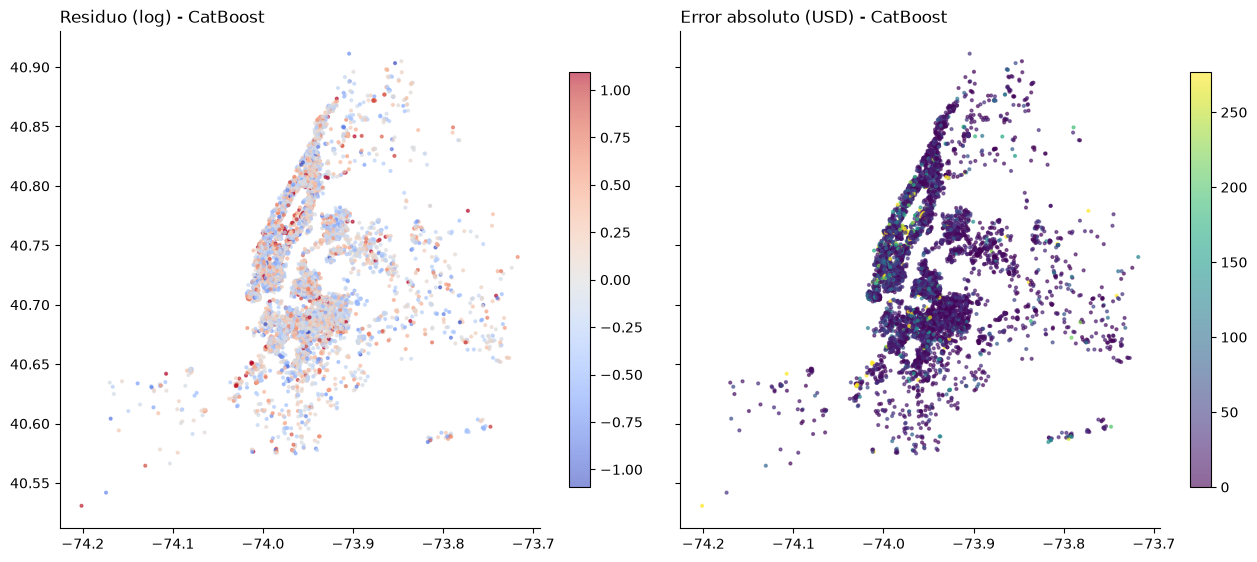

,rmse_log_val,mae_log_val,r2_log_val,mae_usd_val,medae_usd_val,mape_val,n
regla de bloqueo (la usada),0.4292,0.3108,0.6359,49.9287,21.1120,0.3103,7384
sin P99 global (>794 USD),0.3945,0.2979,0.6472,39.0736,20.6522,0.3059,7303


In [16]:
SEGMENTOS_ERROR = [['room_type'], ['district'], ['capacidad'], ['quintil_precio']]
for columnas in SEGMENTOS_ERROR:
    display(error_por_segmento(test, catboost.pred_test, columnas).round(3))
display(peores_errores(test, catboost.pred_test).round(1))
mapa_residuos(test, catboost.pred_test, 'CatBoost')
display(sensibilidad_p99(train, test, catboost.pred_test))

### 6.2 HGB

,n,mae_usd,mediana_usd,mape
room_type,,,,
Entire place,3877,69.266,34.343,0.317
Hotel room,57,168.689,68.948,0.611
Private room,3315,24.903,13.286,0.289
Shared room,135,29.987,13.142,0.422


,n,mae_usd,mediana_usd,mape
district,,,,
Bronx,198,34.889,14.374,0.326
Brooklyn,2889,39.376,17.906,0.297
Manhattan,3294,64.513,29.701,0.326
Queens,945,30.720,13.019,0.280
Staten Island,58,44.120,19.586,0.344


,n,mae_usd,mediana_usd,mape
capacidad,,,,
1,1155,25.588,11.943,0.291
2,3587,37.132,18.854,0.297
3-4,1778,56.603,29.585,0.307
5-6,627,93.576,41.530,0.353
7+,237,180.183,71.441,0.468


,n,mae_usd,mediana_usd,mape
quintil_precio,,,,
Q1 (barato),1547,15.055,11.140,0.387
Q2,1432,20.080,13.942,0.287
Q3,1601,26.985,20.230,0.267
Q4,1339,35.770,28.738,0.241
Q5 (caro),1465,151.275,83.656,0.354


,listing_id,room_type,district,accommodates,bedrooms,price,pred_usd,error_abs_usd
135,2271504,Entire place,Brooklyn,7,3.0,6500,384.0,6116.0
119,2243699,Entire place,Manhattan,16,5.0,5250,1015.8,4234.2
1942,41583926,Entire place,Manhattan,2,5.0,4167,282.3,3884.7
389,30589636,Entire place,Manhattan,4,2.0,3200,141.8,3058.2
1391,40918843,Entire place,Manhattan,1,1.0,2850,144.7,2705.3
323,13963005,Entire place,Queens,6,2.0,2350,145.6,2204.4
2209,42528852,Entire place,Brooklyn,16,3.0,2526,360.8,2165.2
2326,6833395,Entire place,Manhattan,2,1.0,2000,185.4,1814.6
630,23855466,Entire place,Manhattan,2,1.0,2000,196.1,1803.9
82,26496505,Entire place,Queens,2,1.0,1800,91.4,1708.6


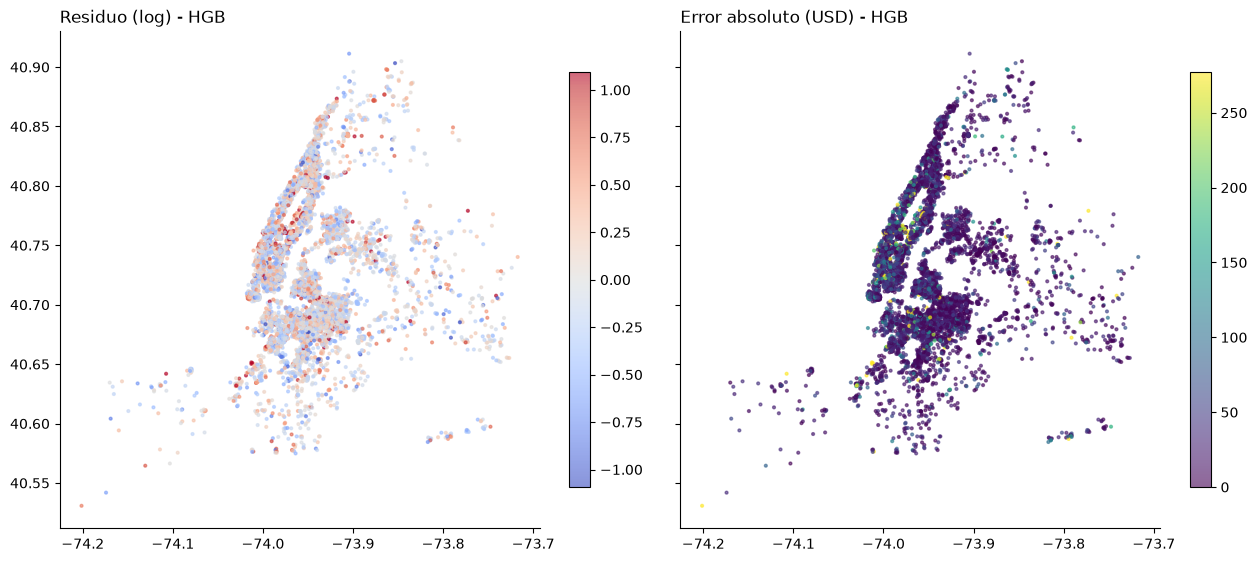

,rmse_log_val,mae_log_val,r2_log_val,mae_usd_val,medae_usd_val,mape_val,n
regla de bloqueo (la usada),0.4239,0.3058,0.6449,49.3989,21.1165,0.3086,7384
sin P99 global (>794 USD),0.3889,0.2929,0.6572,38.4948,20.8433,0.3042,7303


In [17]:
for columnas in SEGMENTOS_ERROR:
    display(error_por_segmento(test, hgb.pred_test, columnas).round(3))
display(peores_errores(test, hgb.pred_test).round(1))
mapa_residuos(test, hgb.pred_test, 'HGB')
display(sensibilidad_p99(train, test, hgb.pred_test))

#### Conclusiones:

- **Dónde fallan más (los dos igual):** pisos enteros (MAE 70 y 69 USD frente a 25 USD en habitaciones privadas),
  habitaciones de hotel (175 y 169 USD, con 57 anuncios), pisos para 7 o más huéspedes (172 y 180 USD, MAPE 43-47 %) y
  Manhattan (66 y 65 USD).
- **Los precios altos pesan en el error absoluto:** en el Q5 el MAE es de 154 y 151 USD, frente a 15-36 USD en el resto de
  quintiles. El MAPE es parecido (35-37 %): el error relativo no empeora tanto, pero un 36 % de 400 USD son muchos dólares.
- **Los 20 peores errores son prácticamente los mismos en los dos modelos:** pisos enteros caros (más de 1.490 USD)
  infravalorados. El peor es un anuncio de 6.500 USD que se predice en 460 (CatBoost) y 384 (HGB). El modelo no captura
  el lujo extremo con las variables disponibles.
- **Sensibilidad a la regla de exclusión:** sin los precios por encima del P99 del train (794 USD, 81 anuncios) el RMSE en
  log baja a 0,395 (CatBoost) y 0,389 (HGB), y el MAE a 39,1 y 38,5 USD. La cola explica cerca de 11 USD del MAE.
- **Mapas de residuos:** en los dos modelos no se aprecian zonas con un sesgo sistemático claro; los residuos grandes
  están repartidos por Manhattan y Brooklyn, donde hay más anuncios y precios más altos.

## 7. INTERPRETACIÓN

Permutación en el test y PDP + ICE en los dos modelos, y SHAP nativo de CatBoost en CatBoost. Los tres anuncios que se
explican por separado se eligen con una regla fijada aquí, antes de mirar su explicación: el de error más cercano a la
mediana, el anuncio del 5 % más caro mejor predicho y el peor error de la sección 6.

### 7.1 CatBoost

In [18]:
bloques_catboost, variables_catboost = importancia_modelo(catboost, test, bloques)
display(bloques_catboost.round(4))
display(variables_catboost.head(15).round(4))

,mean,std
grupo,,
B0_producto,0.2935,0.0042
B1_ubicacion,0.1130,0.0023
B3_amenities_comunes,0.0477,0.0006
B2b_anfitrion,0.0476,0.0020
B2a_condiciones,0.0044,0.0004


,mean,std
grupo,,
accommodates,0.0545,0.0024
room_type,0.0469,0.0011
property_type_grp,0.0347,0.0005
latitude + longitude,0.0284,0.0015
bedrooms,0.0248,0.0010
dist_centro_km,0.0169,0.0004
host_total_listings_count,0.0103,0.0006
neighbourhood,0.0070,0.0004
district,0.0068,0.0004


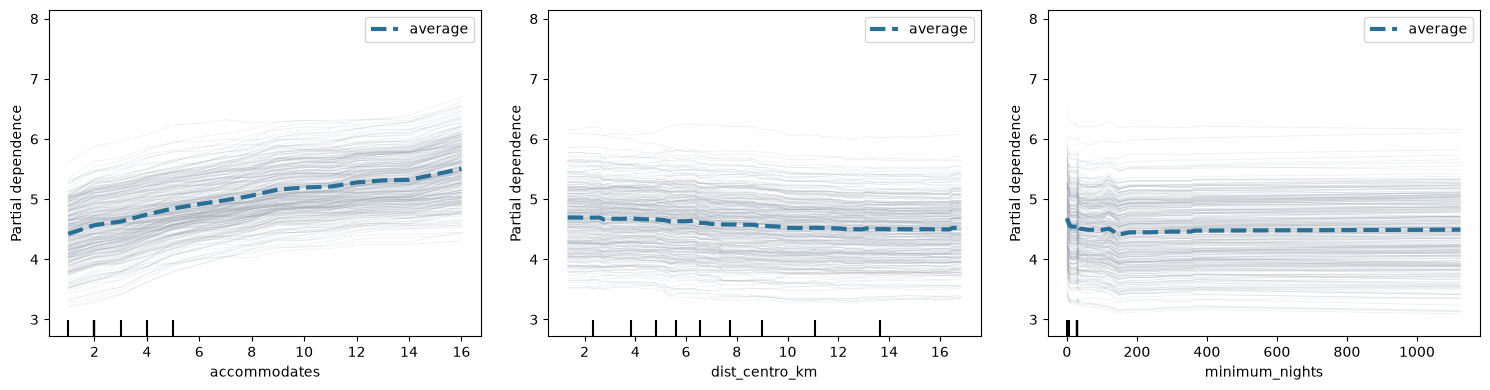

In [19]:
VARIABLES_PDP = ['accommodates', 'dist_centro_km', 'minimum_nights']
grafico_pdp(catboost, test, VARIABLES_PDP, COLOR_BASE, COLOR_SECUNDARIO)

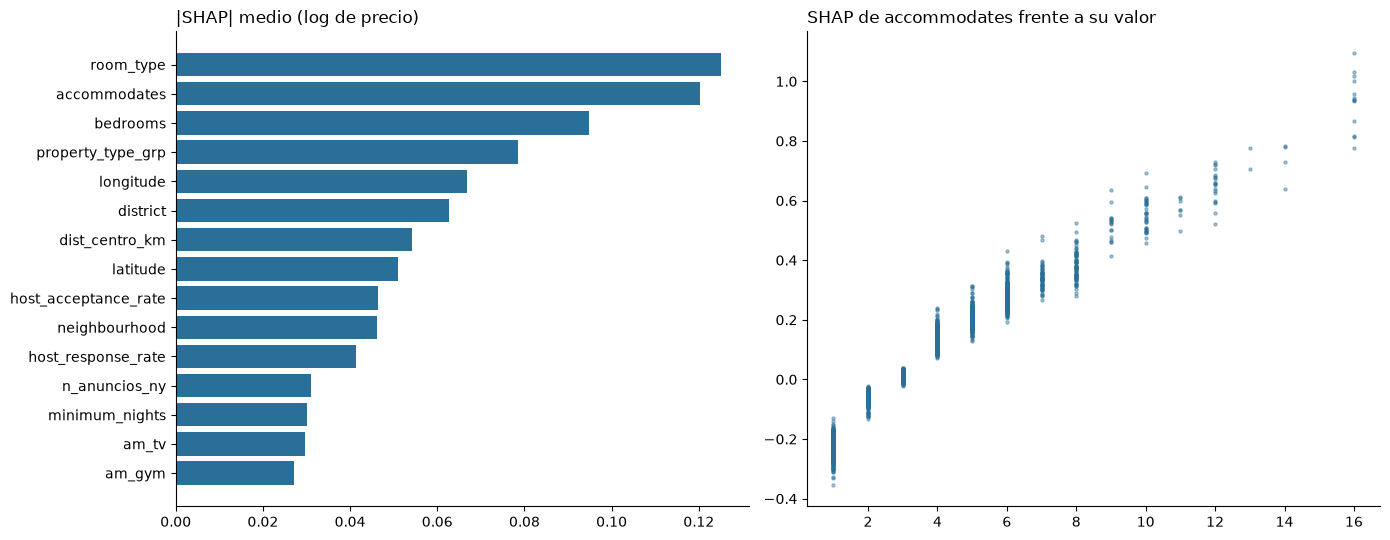

In [20]:
X_test_cb = test[catboost.columnas]
shap_test, valor_base = valores_shap(catboost.modelo, X_test_cb)
shap_medio = pd.Series(np.abs(shap_test).mean(axis=0), index=catboost.columnas).sort_values(ascending=False)
# Las contribuciones mas el valor base suman la prediccion: comprobacion de la implementacion
assert np.allclose(valor_base + shap_test.sum(axis=1), catboost.pred_test, atol=1e-3)

principales = shap_medio.head(15)[::-1]
fig, ejes = plt.subplots(1, 2, figsize=(14, 5.5))
ejes[0].barh(principales.index, principales.values, color=COLOR_BASE)
ejes[0].set_title('|SHAP| medio (log de precio)', loc='left')
numericas = [c for c in shap_medio.index if pd.api.types.is_numeric_dtype(X_test_cb[c]) and X_test_cb[c].nunique() > 2][:1]
for c in numericas:
    ejes[1].scatter(X_test_cb[c], shap_test[:, catboost.columnas.index(c)], s=5, alpha=0.4, color=COLOR_BASE)
    ejes[1].set_title(f'SHAP de {c} frente a su valor', loc='left')
for eje in ejes:
    eje.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [21]:
for etiqueta, pos in anuncios_ilustrativos(test, catboost.pred_test).items():
    contribuciones = pd.Series(shap_test[pos], index=catboost.columnas)
    principales = contribuciones.reindex(contribuciones.abs().sort_values(ascending=False).index).head(6)
    print(f"{etiqueta}: precio real {test['price'].iloc[pos]:.0f} USD, predicho {np.exp(catboost.pred_test[pos]):.0f} USD "
          f"(base {np.exp(valor_base):.0f} USD)")
    display(pd.DataFrame({'valor': X_test_cb.iloc[pos][principales.index], 'shap_log': principales}).round(3))

tipico: precio real 160 USD, predicho 181 USD (base 101 USD)


,valor,shap_log
room_type,Entire place,0.116
longitude,-73.98905,0.108
dist_centro_km,2.368443,0.091
property_type_grp,Entire apartment,0.073
district,Manhattan,0.070
bedrooms,1.0,-0.059


caro bien predicho: precio real 350 USD, predicho 350 USD (base 101 USD)


,valor,shap_log
accommodates,9,0.636
bedrooms,2.0,0.175
antiguedad_host_anios,9.09514,0.126
am_indoor_fireplace,True,0.113
am_cable_tv,True,0.090
latitude,40.80688,0.082


peor error: precio real 6500 USD, predicho 460 USD (base 101 USD)


,valor,shap_log
accommodates,7,0.381
bedrooms,3.0,0.346
am_indoor_fireplace,True,0.157
latitude,40.68766,-0.128
district,Brooklyn,-0.092
am_essentials,False,0.090


### 7.2 HGB

In [22]:
bloques_hgb, variables_hgb = importancia_modelo(hgb, test, bloques)
display(bloques_hgb.round(4))
display(variables_hgb.head(15).round(4))

,mean,std
grupo,,
B0_producto,0.2977,0.0040
B1_ubicacion,0.1086,0.0022
B2b_anfitrion,0.0497,0.0020
B3_amenities_comunes,0.0464,0.0013
B2a_condiciones,0.0045,0.0004


,mean,std
grupo,,
accommodates,0.0481,0.0022
property_type_grp,0.0468,0.0002
room_type,0.0322,0.0013
bedrooms,0.0239,0.0009
neighbourhood,0.0231,0.0014
latitude + longitude,0.0204,0.0012
host_total_listings_count,0.0094,0.0004
host_response_rate,0.0071,0.0008
dist_centro_km,0.0063,0.0008


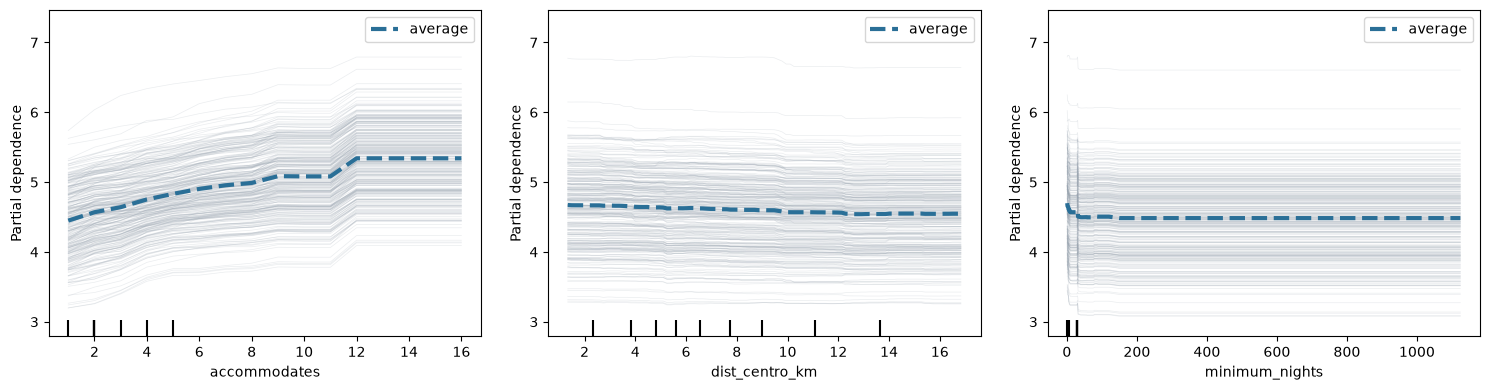

In [23]:
grafico_pdp(hgb, test, VARIABLES_PDP, COLOR_BASE, COLOR_SECUNDARIO)

In [24]:
# HGB no tiene SHAP nativo: se muestran el precio real, el predicho con su intervalo y el valor de las variables mas
# importantes por permutacion (latitud y longitud por separado)
top = variables_hgb.head(8).index
columnas_top = [c for grupo in top for c in (['latitude', 'longitude'] if grupo == 'latitude + longitude' else [grupo])]
filas = []
for etiqueta, pos in anuncios_ilustrativos(test, hgb.pred_test).items():
    filas.append({'anuncio': etiqueta, 'listing_id': test['listing_id'].iloc[pos], 'precio_real': test['price'].iloc[pos],
                  'precio_predicho': np.exp(hgb.pred_test[pos]),
                  'intervalo_bajo': np.exp(hgb.intervalos['CQR'][0][pos]),
                  'intervalo_alto': np.exp(hgb.intervalos['CQR'][1][pos]), **test[columnas_top].iloc[pos].to_dict()})
display(pd.DataFrame(filas).set_index('anuncio').T)

anuncio,tipico,caro bien predicho,peor error
listing_id,2584258,273190,2271504
precio_real,28,900,6500
precio_predicho,49.100816,905.1438,384.002149
intervalo_bajo,32.250827,278.489894,146.436229
intervalo_alto,76.626387,1250.488331,893.682988
accommodates,2,12,7
property_type_grp,Private room in apartment,Entire house,Entire apartment
room_type,Private room,Entire place,Entire place
bedrooms,1.0,6.0,3.0
neighbourhood,Bushwick,West Village,Clinton Hill


#### Conclusiones:

- **Los dos modelos usan la misma información.** Por bloques (aumento del RMSE en log al permutar): producto
  **0,29-0,30** ≫ ubicación **0,11** > anfitrión y amenities **≈ 0,05** ≫ condiciones de reserva **0,004**.
- **Variables:** encabezan `accommodates`, `room_type`, `property_type_grp`, `bedrooms` y la ubicación. La diferencia
  está en cómo reparten la ubicación: HGB da más peso al barrio (0,023 frente a 0,007 en CatBoost, que lo codifica con
  *ordered target statistics*) y CatBoost a la distancia al centro (0,017 frente a 0,006).
- **PDP/ICE:** `accommodates` sube casi de forma continua (en CatBoost, de ~4,4 a ~5,5 en log entre 1 y 16 huéspedes; en
  HGB sube hasta ~5,3 y se aplana a partir de 12). La distancia al centro apenas pesa (baja ~0,2 en log en todo el
  rango) y `minimum_nights` solo marca una caída al pasar de 1 a unas 30 noches, y después es plana. Las curvas ICE son
  casi paralelas: no se ve interacción en estas tres variables.
- **SHAP (CatBoost):** `room_type` (0,125) y `accommodates` (0,120) son las que más contribuyen. La contribución de
  `accommodates` crece de −0,25 con 1 huésped a cerca de +1,0 con 16. En el peor error (6.500 USD predichos 460) el modelo ve un
  piso de 7 huéspedes y 3 dormitorios, y las variables disponibles no lo distinguen de uno corriente.
- **Tres anuncios con HGB:** el típico (28 USD reales) se predice en 49 USD con intervalo 32-77, y el real queda por
  debajo; el caro bien predicho (900 USD) en 905 con intervalo 278-1.250, y el peor error (6.500 USD) en 384 con
  intervalo 146-894, que no lo cubre.
- La permutación, las PDP y SHAP describen cómo usa las variables el **modelo**, no una relación causal con el precio.
  Con variables correlacionadas (p. ej. `accommodates` y `bedrooms`) la importancia de cada una se reparte.

## 8. USO DE LOS MODELOS GUARDADOS

Se carga todo desde disco y se predice un anuncio **en bruto** (filas de `listings.csv`). La cadena es
anuncio en bruto → preparador → modelo → `exp(ŷ)`.

**Aviso:** `n_anuncios_ny` y `reputacion_cartera` se calculan sobre las filas que se pasan (decisión del 09-26).
Para un anfitrión con varios anuncios hay que pasar su cartera completa en Nueva York.

In [25]:
from preparacion_datos import PreparadorListings, RUTA_PREPARADOR, cargar_listings_ny

preparador = PreparadorListings.cargar(RUTA_PREPARADOR)
brutos = cargar_listings_ny(DATA_DIR / 'listings.csv')
for m in (catboost, hgb):
    print(m.nombre)
    display(comprobar_modelo_guardado(m, train, brutos, preparador, MODELS_DIR).round(1))
print('Los modelos guardados predicen igual que los de memoria')

CatBoost


,listing_id,precio_mediano,precio_bajo,precio_alto,precio_real
0,39487508,132.2,76.1,180.5,119
1,43162879,60.3,32.3,81.8,44
2,43163345,57.8,32.3,81.3,44


HGB


,listing_id,precio_mediano,precio_bajo,precio_alto,precio_real
0,39487508,139.6,84.4,235.0,119
1,43162879,60.0,32.6,96.4,44
2,43163345,58.0,32.5,95.8,44


Los modelos guardados predicen igual que los de memoria


In [26]:
for m in (catboost, hgb):
    ficha = guardar_ficha_modelo(m, particion, MODELS_DIR)
    print(m.nombre, json.dumps(ficha['versiones']))

CatBoost {"python": "3.13.14", "catboost": "1.2.10", "scikit-learn": "1.9.0", "pandas": "3.0.5"}
HGB {"python": "3.13.14", "scikit-learn": "1.9.0", "pandas": "3.0.5", "numpy": "2.5.1"}


## 9. COMPARACIÓN FINAL: CATBOOST FRENTE A HGB

Los dos modelos, lado a lado, con lo que ya hemos visto por separado. Es una descripción: **no se elige con el test**.
La diferencia entre ellos se mide además por pares: se remuestrean los mismos anfitriones para los dos modelos, así
que el intervalo de la diferencia es más estrecho que el de cada métrica por separado.

### 9.1 Métricas en validación cruzada y en test

,CatBoost CV,CatBoost test,HGB CV,HGB test,dif test (HGB - CatBoost)
metrica,,,,,
RMSE en log,0.4162,0.4292,0.4191,0.4239,-0.0053
R² en log,0.6574,0.6359,0.6527,0.6449,0.0089
MAE (USD),47.5938,49.9287,48.1328,49.3989,-0.5298
Error mediano (USD),21.4959,21.1120,21.4772,21.1165,0.0045
MAPE,0.3143,0.3103,0.3165,0.3086,-0.0017


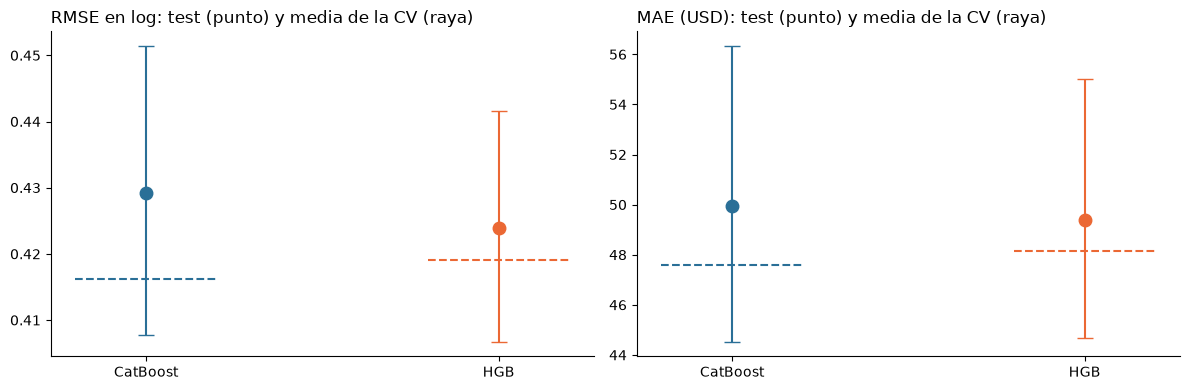

In [27]:
nombres_metricas = {'rmse_log_val': 'RMSE en log', 'r2_log_val': 'R² en log', 'mae_usd_val': 'MAE (USD)',
                    'medae_usd_val': 'Error mediano (USD)', 'mape_val': 'MAPE'}
filas = []
for clave, etiqueta in nombres_metricas.items():
    fila = {'metrica': etiqueta}
    for m in (catboost, hgb):
        fila[f'{m.nombre} CV'] = m.metricas_cv[clave]
        fila[f'{m.nombre} test'] = m.metricas_test[clave]
    fila['dif test (HGB - CatBoost)'] = hgb.metricas_test[clave] - catboost.metricas_test[clave]
    filas.append(fila)
comparacion = pd.DataFrame(filas).set_index('metrica')
display(comparacion.round(4))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for eje, (clave, titulo) in zip(ejes, [('rmse_log_val', 'RMSE en log'), ('mae_usd_val', 'MAE (USD)')]):
    for i, (m, tabla) in enumerate([(catboost, tabla_catboost), (hgb, tabla_hgb)]):
        fila = tabla.loc[clave]
        eje.errorbar(i, fila['test'], yerr=[[fila['test'] - fila['ic95_bajo']], [fila['ic95_alto'] - fila['test']]],
                     fmt='o', color=COLORES[m.nombre], capsize=6, markersize=9, label=f'{m.nombre} (test, IC 95%)')
        eje.plot([i - 0.2, i + 0.2], [m.metricas_cv[clave]] * 2, color=COLORES[m.nombre], ls='--', lw=1.5)
    eje.set_xticks([0, 1], ['CatBoost', 'HGB'])
    eje.set_title(f'{titulo}: test (punto) y media de la CV (raya)', loc='left')
    eje.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 9.2 Diferencia pareada en el test

In [28]:
filas = {}
for clave, etiqueta in [('rmse_log_val', 'RMSE en log'), ('mae_usd_val', 'MAE (USD)'), ('mape_val', 'MAPE')]:
    filas[etiqueta] = diferencia_pareada_bootstrap(hgb, catboost, test, clave)
dif_pareada = pd.DataFrame(filas).T.rename(columns={'valor': 'dif (HGB - CatBoost)',
                                                    'replicas_a_favor_de_a': 'replicas en que gana HGB'})
display(dif_pareada.round(4))

,dif (HGB - CatBoost),ic95_bajo,ic95_alto,replicas en que gana HGB
RMSE en log,-0.0053,-0.0170,0.0030,0.7825
MAE (USD),-0.5298,-2.2465,0.6519,0.6845
MAPE,-0.0017,-0.0091,0.0044,0.6540


### 9.3 Intervalo, coste y errores por segmento

In [29]:
resumen_intervalo = pd.DataFrame({
    m.nombre: {'cobertura CQR': cobertura_intervalo(test[TARGET].to_numpy(), *m.intervalos['CQR']),
               'cobertura sin calibrar': cobertura_intervalo(test[TARGET].to_numpy(), *m.intervalos['sin calibrar']),
               'anchura mediana CQR (USD)': np.median(np.exp(m.intervalos['CQR'][1]) - np.exp(m.intervalos['CQR'][0])),
               'correccion CQR (log)': m.correccion,
               'tiempo de ajuste (s)': m.t_ajuste, 'RMSE en train': m.rmse_train}
    for m in (catboost, hgb)})
display(resumen_intervalo.round(3))

segmentos = {}
for columna in ['room_type', 'capacidad', 'quintil_precio']:
    for m in (catboost, hgb):
        tabla = error_por_segmento(test, m.pred_test, [columna])['mae_usd']
        for valor, mae in tabla.items():
            segmentos.setdefault((columna, valor), {})[m.nombre] = mae
mae_segmentos = pd.DataFrame(segmentos).T.rename_axis(['segmento', 'valor'])
mae_segmentos['dif (HGB - CatBoost)'] = mae_segmentos['HGB'] - mae_segmentos['CatBoost']
display(mae_segmentos.round(1))

,CatBoost,HGB
cobertura CQR,0.779,0.790
cobertura sin calibrar,0.709,0.721
anchura mediana CQR (USD),94.316,93.000
correccion CQR (log),0.067,0.066
tiempo de ajuste (s),220.531,9.925
RMSE en train,0.317,0.363


CatBoost    HGB  dif (HGB - CatBoost)
segmento       valor                                              
room_type      Entire place      70.4   69.3                  -1.1
               Hotel room       175.1  168.7                  -6.4
               Private room      24.6   24.9                   0.3
               Shared room       30.0   30.0                  -0.0
capacidad      1                 25.7   25.6                  -0.1
               2                 38.3   37.1                  -1.2
               3-4               57.2   56.6                  -0.6
               5-6               93.9   93.6                  -0.3
               7+               172.5  180.2                   7.7
quintil_precio Q1 (barato)       14.9   15.1                   0.1
               Q2                19.6   20.1                   0.5
               Q3                27.5   27.0                  -0.5
               Q4                35.6   35.8                   0.1
               Q5 (caro)        154.1  151.3                  -2.8

### 9.4 Importancia por bloque de variables

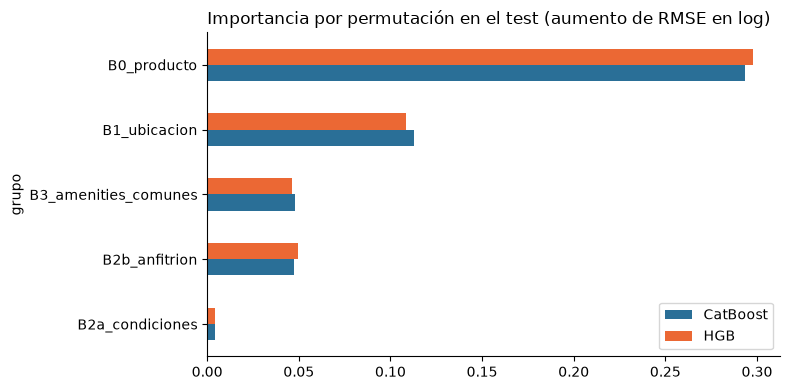

,CatBoost,HGB
grupo,,
B2a_condiciones,0.0044,0.0045
B2b_anfitrion,0.0476,0.0497
B3_amenities_comunes,0.0477,0.0464
B1_ubicacion,0.1130,0.1086
B0_producto,0.2935,0.2977


In [30]:
import_bloques = pd.DataFrame({'CatBoost': bloques_catboost['mean'], 'HGB': bloques_hgb['mean']}).sort_values(
    'CatBoost', ascending=True)
eje = import_bloques.plot.barh(figsize=(8, 4), color=[COLORES['CatBoost'], COLORES['HGB']])
eje.set_title('Importancia por permutación en el test (aumento de RMSE en log)', loc='left')
eje.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
display(import_bloques.round(4))

#### Conclusiones:

- **En validación gana CatBoost, en el test gana HGB, y ninguna de las dos diferencias es concluyente.** CV: 0,4162
  frente a 0,4191 (CatBoost mejor en 5 de 5 folds). Test: 0,4292 frente a 0,4239 (HGB mejor).
- **Diferencia pareada en el test:** HGB − CatBoost = −0,0053 en RMSE en log, con IC 95 % de −0,0170 a +0,0030, que
  contiene el cero (HGB gana en el 78 % de las réplicas). En MAE son −0,53 USD (−2,25 a +0,65) y en MAPE −0,17 puntos:
  tampoco se distinguen.
- **Intervalo:** casi idéntico (cobertura 77,9 % y 79,0 %, anchura 94 y 93 USD), y los dos fallan en el mismo sitio:
  los precios altos (Q5) y Manhattan.
- **Por segmento:** no hay un modelo mejor en todos. HGB es algo mejor en pisos enteros y hoteles, y CatBoost en pisos de
  7 o más huéspedes (172 frente a 180 USD). Las diferencias son pequeñas frente al error.
- **Importancia:** casi la misma por bloques (producto 0,29-0,30, ubicación 0,11, anfitrión ≈ 0,05, amenities ≈ 0,05).
- **Coste:** CatBoost tarda unos 220 s en ajustarse y HGB unos 10 s. CatBoost se ajusta más al train (RMSE 0,318 frente a
  0,363) y aun así no generaliza mejor en el test.
- **Qué queda por decidir:** como no hay base estadística para preferir uno por precisión, la decisión es de coste y
  simplicidad (HGB: un pipeline de scikit-learn sin dependencia extra y 20 veces más rápido) frente a explicabilidad
  adicional (SHAP nativo en CatBoost). Es lo que se va a hablar con la tutora.

## 10. CONCLUSIONES Y RECOMENDACIONES

**Para el analista:** resultado de los dos modelos en el test con su intervalo, comparación con la CV y qué funciona y
dónde falla.

**Para el sponsor:** «un anuncio nuevo se predice con un error típico de X dólares», qué influye en el precio y el rango.

**Qué estima el modelo:** `exp(ŷ)` es la **mediana** del precio, no la media. Si hiciera falta la media, *smearing* de
Duan.

**Limitaciones:** el perfil del anfitrión se mide en 2021, no al publicar (escenario B); los datos son de un único
momento; la CQR con un solo conjunto de calibración es aproximada; la importancia por permutación, las PDP y SHAP no
son causales; el test se abre una sola vez en este notebook pero ya se había abierto antes con cada modelo por
separado, sin usarlo para elegir.

**Líneas futuras:** variables del título, reseñas como complemento en un escenario C, otra ventana temporal.

#### Conclusiones:

- **Para el analista:** los dos modelos predicen el precio con un RMSE en log de 0,424-0,429 (R² 0,636-0,645), un MAE de
  unos 50 USD, un error mediano de 21 USD y un MAPE de 31 %. Son coherentes con la validación cruzada y no se
  distinguen estadísticamente entre sí.
- **Para el sponsor:** un anuncio nuevo se predice con un error típico (mediano) de unos 21 dólares y un error medio de
  unos 50. El intervalo del 80 % cubre en conjunto el 78-79 %, pero solo el 56-58 % en el quinto de anuncios más
  caros, donde no es fiable.
- **Qué influye en el precio:** sobre todo la capacidad, el tipo de alojamiento y de propiedad y los dormitorios,
  después la ubicación, y por último el perfil del anfitrión y las amenities, con un peso parecido entre sí.
- **Decisión pendiente:** qué modelo se presenta como final o si se presentan los dos (ver sección 9).